In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from scikeras.wrappers import KerasClassifier

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

import kagglehub

CSV_PATH = kagglehub.dataset_download("mdssh784/pima-indians-diabetes-dataset") + "/diabetes.csv"

TARGET_COLUMN = "Outcome"

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


In [5]:
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"{CSV_PATH} was not found. Upload your CSV and change CSV_PATH above."
    )

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
display(df.isnull().sum())
print("\nClass distribution:")
display(df[TARGET_COLUMN].value_counts())
print("\nSummary statistics:")
display(df.describe())


Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Class distribution:


Outcome
0    500
1    268
Name: count, dtype: int64


Summary statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
if TARGET_COLUMN not in df.columns:
    raise ValueError(f"{TARGET_COLUMN} not found. Available columns: {df.columns.tolist()}")

X = df.drop(columns=[TARGET_COLUMN]).apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")

valid = X.notna().all(axis=1) & y.notna()
X = X.loc[valid]
y = y.loc[valid].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)


Train: (614, 8)
Test: (154, 8)


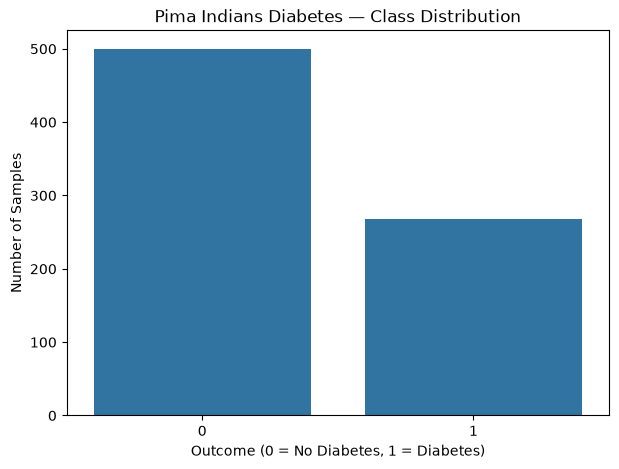

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title("Pima Indians Diabetes — Class Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Samples")
plt.show()


In [8]:
def create_model(
    learning_rate=0.001,
    init_mode="uniform",
    activation="relu",
    dropout_rate=0.0,
    neurons=16
):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dense(
            neurons, activation=activation,
            kernel_initializer=init_mode
        ),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(
            max(neurons // 2, 4), activation=activation,
            kernel_initializer=init_mode
        ),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(
            1, activation="sigmoid",
            kernel_initializer=init_mode
        )
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

classifier = KerasClassifier(
    model=create_model,
    verbose=0,
    random_state=SEED
)


In [9]:
param_grid = {
    "batch_size": [16, 32],
    "epochs": [30, 60],
    "model__learning_rate": [0.001, 0.0001],
    "model__init_mode": ["uniform", "he_uniform"],
    "model__activation": ["relu", "tanh"],
    "model__dropout_rate": [0.0, 0.2],
    "model__neurons": [16, 32]
}

n_combinations = np.prod([len(v) for v in param_grid.values()])
print("Parameter combinations:", int(n_combinations))
print("Approximate model fits with cv=3:", int(n_combinations * 3))


Parameter combinations: 128
Approximate model fits with cv=3: 384


In [10]:
grid = GridSearchCV(
    estimator=classifier,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=1,
    verbose=2,
    refit=True
)

grid_result = grid.fit(X_train_scaled, y_train)

print("\nBest CV accuracy:", grid_result.best_score_)
print("\nBest parameters:")
print(grid_result.best_params_)


Fitting 3 folds for each of 128 candidates, totalling 384 fits


E0000 00:00:1790580938.662458  237140 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
E0000 00:00:1790580939.121655  237140 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1790580946.811790  237140 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset

[CV] END batch_size=16, epochs=30, model__activation=relu, model__dropout_rate=0.0, model__init_mode=uniform, model__learning_rate=0.001, model__neurons=16; total time=   8.5s


E0000 00:00:1790580955.673547  237140 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


[CV] END batch_size=16, epochs=30, model__activation=relu, model__dropout_rate=0.0, model__init_mode=uniform, model__learning_rate=0.001, model__neurons=16; total time=   8.8s


...

[CV] END batch_size=32, epochs=60, model__activation=tanh, model__dropout_rate=0.2, model__init_mode=he_uniform, model__learning_rate=0.0001, model__neurons=32; total time=  10.3s


E0000 00:00:1790583940.252131  237140 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


[CV] END batch_size=32, epochs=60, model__activation=tanh, model__dropout_rate=0.2, model__init_mode=he_uniform, model__learning_rate=0.0001, model__neurons=32; total time=   9.9s


E0000 00:00:1790583949.791904  237140 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


[CV] END batch_size=32, epochs=60, model__activation=tanh, model__dropout_rate=0.2, model__init_mode=he_uniform, model__learning_rate=0.0001, model__neurons=32; total time=   9.5s

Best CV accuracy: 0.7801689781603699

Best parameters:
{'batch_size': 32, 'epochs': 30, 'model__activation': 'tanh', 'model__dropout_rate': 0.2, 'model__init_mode': 'uniform', 'model__learning_rate': 0.001, 'model__neurons': 16}


In [11]:
results = pd.DataFrame(grid_result.cv_results_)

show_cols = [
    "rank_test_score", "mean_test_score", "std_test_score",
    "param_batch_size", "param_epochs",
    "param_model__learning_rate", "param_model__init_mode",
    "param_model__activation", "param_model__dropout_rate",
    "param_model__neurons"
]

display(results[show_cols].sort_values("rank_test_score").head(15))


,rank_test_score,mean_test_score,std_test_score,param_batch_size,param_epochs,param_model__learning_rate,param_model__init_mode,param_model__activation,param_model__dropout_rate,param_model__neurons
88,1,0.780169,0.016913,32,30,0.001,uniform,tanh,0.2,16
24,2,0.780161,0.013917,16,30,0.001,uniform,tanh,0.2,16
97,3,0.778551,0.023609,32,60,0.001,uniform,relu,0.0,32
16,4,0.778535,0.014621,16,30,0.001,uniform,tanh,0.0,16
64,5,0.776917,0.020008,32,30,0.001,uniform,relu,0.0,16
80,5,0.776917,0.019199,32,30,0.001,uniform,tanh,0.0,16
17,7,0.776909,0.015635,16,30,0.001,uniform,tanh,0.0,32
81,7,0.776909,0.015635,32,30,0.001,uniform,tanh,0.0,32
89,7,0.776909,0.015635,32,30,0.001,uniform,tanh,0.2,32
65,7,0.776909,0.019678,32,30,0.001,uniform,relu,0.0,32


In [12]:
best_model = grid_result.best_estimator_

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "AUROC": roc_auc_score(y_test, y_prob)
}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["No Diabetes", "Diabetes"],
    zero_division=0
))


E0000 00:00:1790584075.198197  237140 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Accuracy: 0.7338
Precision: 0.6275
Recall: 0.5926
F1-score: 0.6095
AUROC: 0.8231

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.81      0.80       100
    Diabetes       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



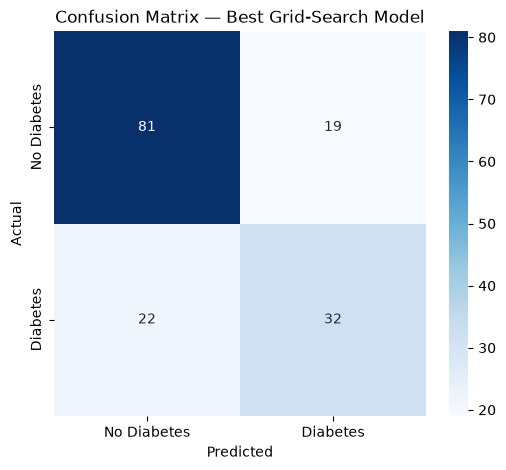

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Best Grid-Search Model")
plt.show()
